# Rekurencyjne sieci neuronowe

### Pobranie danych

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_absolute_error
import keras

In [ ]:
tf.keras.utils.get_file(
    "bike_sharing_dataset.zip",
    "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip",
    cache_dir=".",
    extract=True
)

 270336/Unknown 1s 5us/step

'./datasets/bike_sharing_dataset_extracted'

### Przygotowanie danych

In [ ]:
df = pd.read_csv('datasets/bike_sharing_dataset_extracted/hour.csv')
df['datetime'] = pd.to_datetime(df['dteday'] + ' ' + df['hr'].astype(str).str.zfill(2), format='%Y-%m-%d %H')
df.set_index('datetime', inplace=True)
df.drop(columns=['instant', 'dteday', 'season', 'yr', 'mnth', 'hr'], inplace=True)

In [ ]:
df.head()

,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
datetime,,,,,,,,,,,
2011-01-01 00:00:00,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2011-01-01 01:00:00,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2011-01-01 02:00:00,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
2011-01-01 03:00:00,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
2011-01-01 04:00:00,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
# zakres
print((df.index.min(), df.index.max()))

(Timestamp('2011-01-01 00:00:00'), Timestamp('2012-12-31 23:00:00'))


In [ ]:
(365 + 366)*24 - len(df)

165

Okazuje się że w DataFrame mamy okresy(godziny), podczas których nikt nie korzystał z rowerów.

In [ ]:
# Utworzenie obiektu resampler
resampler = df.resample("H")
df_resampled = resampler.asfreq()
df_resampled[['casual', 'registered', 'cnt']] = df_resampled[['casual', 'registered', 'cnt']].fillna(0)
df_resampled[['temp', 'atemp', 'hum', 'windspeed']] = df_resampled[['temp', 'atemp', 'hum', 'windspeed']].interpolate(method='linear')
df_resampled[['holiday', 'weekday', 'workingday', 'weathersit']] = df_resampled[['holiday', 'weekday', 'workingday', 'weathersit']].ffill()
df_resampled

<ipython-input-7-676891266>:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampler = df.resample("H")


,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
datetime,,,,,,,,,,,
2011-01-01 00:00:00,0.0,6.0,0.0,1.0,0.24,0.2879,0.81,0.0000,3.0,13.0,16.0
2011-01-01 01:00:00,0.0,6.0,0.0,1.0,0.22,0.2727,0.80,0.0000,8.0,32.0,40.0
2011-01-01 02:00:00,0.0,6.0,0.0,1.0,0.22,0.2727,0.80,0.0000,5.0,27.0,32.0
2011-01-01 03:00:00,0.0,6.0,0.0,1.0,0.24,0.2879,0.75,0.0000,3.0,10.0,13.0
2011-01-01 04:00:00,0.0,6.0,0.0,1.0,0.24,0.2879,0.75,0.0000,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,0.0,1.0,1.0,2.0,0.26,0.2576,0.60,0.1642,11.0,108.0,119.0
2012-12-31 20:00:00,0.0,1.0,1.0,2.0,0.26,0.2576,0.60,0.1642,8.0,81.0,89.0
2012-12-31 21:00:00,0.0,1.0,1.0,1.0,0.26,0.2576,0.60,0.1642,7.0,83.0,90.0


In [ ]:
# sprawdzenie czy df nie zawiera brakujących wartości
df_resampled.notna().sum()

,0
holiday,17544
weekday,17544
workingday,17544
weathersit,17544
temp,17544
atemp,17544
hum,17544
windspeed,17544
casual,17544
registered,17544


In [ ]:
# normalizacja kolumn [['casual', 'registered', 'cnt', 'weathersit']]
df_resampled[['casual', 'registered', 'cnt', 'weathersit']].describe()

,casual,registered,cnt,weathersit
count,17544.000000,17544.000000,17544.000000,17544.000000
mean,35.340686,152.340515,187.681202,1.434223
std,49.193293,151.373409,181.456478,0.648339
min,0.000000,0.000000,0.000000,1.000000
25%,4.000000,32.000000,38.000000,1.000000
50%,16.000000,114.000000,140.000000,1.000000
75%,48.000000,219.000000,279.000000,2.000000
max,367.000000,886.000000,977.000000,4.000000


In [ ]:
df_resampled.casual /= 1e3
df_resampled.registered /= 1e3
df_resampled.cnt /= 1e3
df_resampled.weathersit /= 4
df_resampled[['casual', 'registered', 'cnt', 'weathersit']].describe()

,casual,registered,cnt,weathersit
count,17544.000000,17544.000000,17544.000000,17544.000000
mean,0.035341,0.152341,0.187681,0.358556
std,0.049193,0.151373,0.181456,0.162085
min,0.000000,0.000000,0.000000,0.250000
25%,0.004000,0.032000,0.038000,0.250000
50%,0.016000,0.114000,0.140000,0.250000
75%,0.048000,0.219000,0.279000,0.500000
max,0.367000,0.886000,0.977000,1.000000


<Axes: xlabel='datetime'>

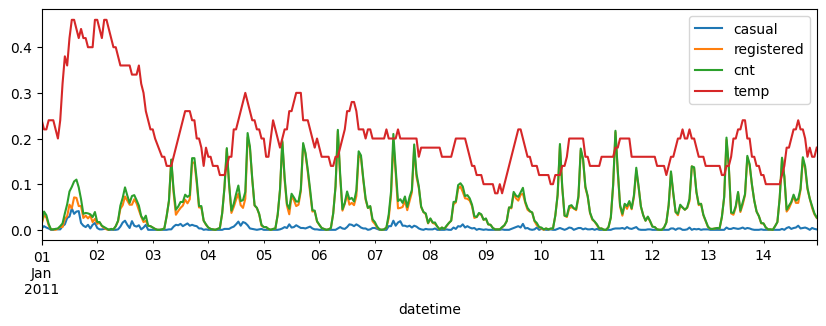

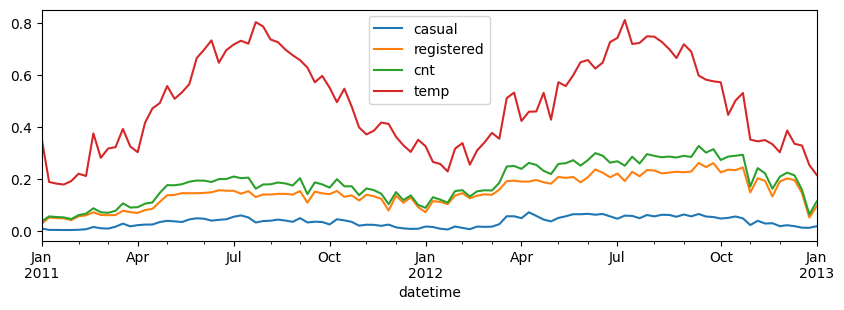

In [ ]:
# Wizualizacja danych
df_2weeks = df_resampled[:24 * 7 * 2]
df_2weeks[['casual', 'registered', 'cnt', 'temp']].plot(figsize=(10,3))

df_daily = df_resampled.resample('W').mean()
df_daily[['casual', 'registered', 'cnt', 'temp']].plot(figsize=(10,3))

### Wskaźniki bazowe

In [ ]:
# Zastosujemy wskaźniki "naiwne" jako punkt odniesienia do oceny naszego przyszłego, bardziej złożonego modelu

#predykcja dla cyklu dobowego
#shift "przesuwa" wartości dataframe o jakiś interwał
# iloc[], żeby ignorować wiersze gdzie jest NaN
day_pred_cnt = df_resampled['cnt'].shift(24) * 1e3
mae_daily = mean_absolute_error(df_resampled['cnt'].iloc[24:] * 1e3, day_pred_cnt.iloc[24:])

#predykcja dla cyklu tygodniowego
week_pred_cnt = df_resampled['cnt'].shift(24 * 7) * 1e3
mae_weekly = mean_absolute_error(df_resampled['cnt'].iloc[24*7:] * 1e3, week_pred_cnt.iloc[24*7:])
print(f"MAE daily = {mae_daily}")
print(f"MAE weekly = {mae_weekly}")

with open("mae_baseline.pkl", 'wb') as file:
  pickle.dump((mae_daily, mae_weekly), file)

MAE daily = 63.79497716894977
MAE weekly = 52.42506906077348


## Przygotowanie modeli

### Predykcja za pomocą sieci gęstej

In [ ]:
cnt_train = df_resampled['cnt']['2011-01-01 00:00':'2012-06-30 23:00']
cnt_valid = df_resampled['cnt']['2012-07-01 00:00':]

seq_len = 1 * 24
train_ds = tf.keras.utils.timeseries_dataset_from_array(
            cnt_train.to_numpy(),
            targets=cnt_train.to_numpy()[seq_len:],
            sequence_length=seq_len,
            batch_size=32,
            shuffle=True,
            seed=42
            )

valid_ds = tf.keras.utils.timeseries_dataset_from_array(
            cnt_valid.to_numpy(),
            targets=cnt_valid.to_numpy()[seq_len:],
            sequence_length=seq_len,
            batch_size=32
            )

In [ ]:
model_linear = tf.keras.Sequential([
    tf.keras.Input(shape=(seq_len,)),
    tf.keras.layers.Dense(1)
])

model_linear.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9), loss='huber', metrics=['mae'])

### Prosta sieć rekurencyjna

In [ ]:
# Simple rnn
model_rnn1 = tf.keras.Sequential([
    tf.keras.Input(shape=(None, 1)),
    tf.keras.layers.LSTM(1),
    tf.keras.layers.Dense(1)
])
model_rnn1.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9), loss='huber', metrics=['mae'])

# Troche bardziej rozbudowany model z większą ilością neuronów i warstwą Dense na wyjściu
model_rnn2 = tf.keras.Sequential([
    tf.keras.Input(shape=(None, 1)),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])
model_rnn2.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9), loss='huber', metrics=['mae'])

### Głęboka RNN

In [ ]:
model_rnn_deep = tf.keras.Sequential([
    tf.keras.Input(shape=(None, 1)),
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.Dense(1)
])
model_rnn_deep.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9), loss='huber', metrics=['mae'])

Żeby dobrać odpowiednie `learning_rate` wykorzystamy **scheduler learning rate** `ReduceLROnPlateau`, który automatycznie zmniejsza `learning_rate` gdy postęp w treningu się zatrzymuje, czyli kiedy monitorowana metryka nie poprawia się przez określoną liczbe epok `patience`

In [ ]:
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=1e-6)

In [ ]:
# Drugi callback EarlyStopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5);

### Model wielowymiarowy

In [ ]:
cnt_train_2 = df_resampled[['cnt', 'weathersit', 'atemp', 'workingday']]['2011-01-01 00:00':'2012-06-30 23:00']
cnt_valid_2 = df_resampled[['cnt', 'weathersit', 'atemp', 'workingday']]['2012-07-01 00:00':]
cnt_y_train = df_resampled['cnt']['2011-01-01 00:00':'2012-06-30 23:00']
cnt_y_valid = df_resampled['cnt']['2012-07-01 00:00':]
seq_len = 1 * 24

train_ds_2 = tf.keras.utils.timeseries_dataset_from_array(
    cnt_train_2.to_numpy(),
    targets = cnt_y_train.to_numpy()[seq_len:],
    sequence_length=seq_len,
    batch_size=32,
    shuffle=True,
    seed=42
)

valid_ds_2 = tf.keras.utils.timeseries_dataset_from_array(
    data=cnt_valid_2.to_numpy(),
    targets = cnt_y_valid.to_numpy()[seq_len:],
    sequence_length=seq_len,
    batch_size=32
)

In [ ]:
import keras

model_rnn_dim = tf.keras.models.Sequential([
    tf.keras.Input(shape=[None, 4]),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])
model_rnn_dim.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9), loss='huber', metrics=['mae'])

## Trenowanie modeli

In [ ]:
model_linear.fit(train_ds, epochs=20, validation_data=valid_ds, callbacks=[reduce_lr_cb, es])

mae_linear = model_linear.evaluate(valid_ds)[1]
print(f"Dla modelu liniowego MAE = {mae_linear * 1e3}")
model_linear.save("model_linear.keras")
with open("mae_linear", "wb") as file:
  pickle.dump((mae_linear * 1e3, ), file)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0091 - mae: 0.0900 - val_loss: 0.0044 - val_mae: 0.0657 - learning_rate: 0.1000
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0022 - mae: 0.0465 - val_loss: 0.0038 - val_mae: 0.0603 - learning_rate: 0.1000
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0020 - mae: 0.0429 - val_loss: 0.0036 - val_mae: 0.0575 - learning_rate: 0.1000
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0019 - mae: 0.0417 - val_loss: 0.0039 - val_mae: 0.0632 - learning_rate: 0.1000
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0019 - mae: 0.0420 - val_loss: 0.0037 - val_mae: 0.0612 - learning_rate: 0.1000
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0019 - mae: 0.0413 - val_loss: 0.0034 - val_mae: 0.0562 - learning_rate: 0.1000
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0018 - mae: 0.0405 - val_loss: 0.0035 - val_mae: 0.0563 - learning_rate: 0.1000
Epo

In [ ]:
model_rnn1.fit(train_ds, epochs=20, validation_data=valid_ds, callbacks=[reduce_lr_cb, es])

mae_rnn1 = model_rnn1.evaluate(valid_ds)[1]
print(f"Dla modelu rekurencyjnego 1 (prostego) MAE = {mae_rnn1* 1e3}")
model_rnn1.save("model_rnn1.keras")
with open("mae_rnn1", "wb") as file:
  pickle.dump((mae_rnn1 * 1e3,), file)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0123 - mae: 0.1212 - val_loss: 0.0116 - val_mae: 0.1125 - learning_rate: 0.1000
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 0.0051 - mae: 0.0732 - val_loss: 0.0089 - val_mae: 0.0884 - learning_rate: 0.1000
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0039 - mae: 0.0618 - val_loss: 0.0075 - val_mae: 0.0780 - learning_rate: 0.1000
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0034 - mae: 0.0556 - val_loss: 0.0068 - val_mae: 0.0734 - learning_rate: 0.1000
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0032 - mae: 0.0532 - val_loss: 0.0066 - val_mae: 0.0728 - learning_rate: 0.1000
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0031 - mae: 0.0522 - val_loss: 0.0062 - val_mae: 0.0723 - learning_rate: 0.1000
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0031 - mae: 0.0524 - val_loss: 0.0062 - val_mae: 0.0719 - learning_rate: 0.1

In [ ]:
model_rnn2.fit(train_ds, epochs=20, validation_data=valid_ds, callbacks=[reduce_lr_cb, es])

mae_rnn2 = model_rnn2.evaluate(valid_ds)[1]
print(f"Dla modelu rekurencyjnego 2 (średnio złożonego) MAE = {mae_rnn2* 1e3}")
model_rnn2.save("model_rnn32.keras")
with open("mae_rnn32", "wb") as file:
  pickle.dump((mae_rnn2 * 1e3,), file)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.0090 - mae: 0.0999 - val_loss: 0.0113 - val_mae: 0.0966 - learning_rate: 0.1000
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0051 - mae: 0.0699 - val_loss: 0.0091 - val_mae: 0.0895 - learning_rate: 0.1000
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0044 - mae: 0.0640 - val_loss: 0.0087 - val_mae: 0.0852 - learning_rate: 0.1000
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0041 - mae: 0.0609 - val_loss: 0.0077 - val_mae: 0.0810 - learning_rate: 0.1000
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0038 - mae: 0.0568 - val_loss: 0.0071 - val_mae: 0.0767 - learning_rate: 0.1000
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0035 - mae: 0.0544 - val_loss: 0.0071 - val_mae: 0.0845 - learning_rate: 0.1000
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0034 - mae: 0.0535 - val_loss: 0.0063 - val_mae: 0.0689 - learning_rate: 

In [ ]:
model_rnn_deep.fit(train_ds, epochs=20, validation_data=valid_ds, callbacks=[reduce_lr_cb, es])

mae_rnn_deep = model_rnn_deep.evaluate(valid_ds)[1]
print(f"Dla modelu rekurencyjnego deep (złożonego) MAE = {mae_rnn_deep* 1e3}")
model_rnn_deep.save("model_rnn_deep.keras")
with open("mae_rnn_deep", "wb") as file:
  pickle.dump((mae_rnn_deep * 1e3,), file)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - loss: 0.0142 - mae: 0.1323 - val_loss: 0.0270 - val_mae: 0.1759 - learning_rate: 0.1000
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0135 - mae: 0.1298 - val_loss: 0.0266 - val_mae: 0.1755 - learning_rate: 0.1000
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 0.0134 - mae: 0.1291 - val_loss: 0.0316 - val_mae: 0.1853 - learning_rate: 0.1000
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - loss: 0.0135 - mae: 0.1297 - val_loss: 0.0272 - val_mae: 0.1764 - learning_rate: 0.1000
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0134 - mae: 0.1295
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.010000000149011612.
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - loss: 0.0134 - mae: 0.1295 - val_loss: 0.0287 - val_mae: 0.1790 - learning_rate: 0.1000
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.0131 - mae: 0.1279 - val_loss: 0.0280 - val_mae: 0.1777 - learning_rat

In [ ]:
model_rnn_dim.fit(train_ds_2, epochs=20, validation_data=valid_ds_2, callbacks=[reduce_lr_cb, es])

mae_rnn_dim = model_rnn_dim.evaluate(valid_ds_2)[1]
print(f"Dla modelu rekurencyjnego wielowymiarowego: MAE = {mae_rnn_dim* 1e3}")
model_rnn_dim.save("model_rnn_mv.keras")
with open("mae_rnn_mv", "wb") as file:
  pickle.dump((mae_rnn_dim * 1e3,), file)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.0084 - mae: 0.0957 - val_loss: 0.0107 - val_mae: 0.0928 - learning_rate: 0.1000
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0046 - mae: 0.0663 - val_loss: 0.0082 - val_mae: 0.0827 - learning_rate: 0.1000
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0040 - mae: 0.0609 - val_loss: 0.0082 - val_mae: 0.0811 - learning_rate: 0.1000
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0037 - mae: 0.0579 - val_loss: 0.0073 - val_mae: 0.0771 - learning_rate: 0.1000
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0035 - mae: 0.0561 - val_loss: 0.0073 - val_mae: 0.0770 - learning_rate: 0.1000
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0034 - mae: 0.0563 - val_loss: 0.0070 - val_mae: 0.0753 - learning_rate: 0.1000
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0032 - mae: 0.0528 - val_loss: 0.0062 - val_mae: 0.0723 - learning_rate: 0